# BK2 physics: Simulation of a mass on a spring

## Introduction
we are introduced to Oscillations in Physics which is a fundamental concept in physics and with wide range of application in science and technology
. We learned about oscillation specially in two ways. First one is the simulation way where we are simulating the classical mass-spring system, where we learned about the theoretical aspects and mathematical descriptions of oscillatory motion and second one we are doing parctical experiments involving electrical circuits, where we measured voltage and current using oscilloscope. 

Taking about the goal, it is to provide the comprehensive understanding of oscillation.  Through, the simulation of classical mass-spring system, we are developing a foundation in mathematical modelling of oscillaroty motion and this understanding is futher reinforced through practical experiments involving electrical circuits. We also learned to collect data and analyze data.


## Theory


Consider a bead of mass $m$ on a spring with spring constant $k$.


Hooke's law: $F = -kx$

Newton's second law: $F = ma$


## Simulation

We will setup a numerical simulation using the Python programming language.

First we import the packages that we need:

In [33]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

In [34]:
def LeapFrog(m, k, dt, t_end, v0, x0):
    """ Run a numerical simulation of a mass and a spring using Leap-Frog.
    Parameters:
        m: mass attached to spring
        k: spring constant
        dt: timestep
        t_end: total amount of step
        v0: initial velocity
        x0: initial distance/position
    Returns:
        ttable: table with time
        xtable: table with position 
        vtable: table with velocity
    """
    
    n_steps = int(t_end/dt)  # Number of steps
    
    ttable = np.zeros(n_steps)
    xtable = np.zeros(n_steps)
    vtable = np.zeros(n_steps)
    
    t = 0.0
    x = x0
    v = v0
    
    for i in range(n_steps):
        ttable[i] = t
        xtable[i] = x
        vtable[i] = v
        
        t = t + dt
        a = -(k*x)/m
        v = v + a*dt  # a = dv/dt
        x = x + v*dt  # v = dx/dt
        

    
    return ttable,xtable,vtable

If you wrote good desciptions of the parameters, the function should give some descriptive help:

In [3]:
help(LeapFrog)

Help on function LeapFrog in module __main__:

LeapFrog(m, k, dt, t_end, v0, x0)
    Run a numerical simulation of a mass and a spring using Leap-Frog.
    Parameters:
        m: mass attached to spring
        k: spring constant
        dt: timestep
        t_end: total amount of step
        v0: initial velocity
        x0: initial distance/position
    Returns:
        ttable: table with time
        xtable: table with position
        vtable: table with velocity



Now we are ready to run the simulation:

** NOTE: you have to insert the numbers describing the simulation you want **

In [58]:
ttable,xtable,vtable = LeapFrog(m=0.2, k=10, dt=0.01, t_end=3, v0=0, x0=0.1)   

The result of the simulation is now stored in the tables, ttable, xtable, and vtable

In [50]:
#print(xtable)
    

Let's plot x as a function of t, using the data stored in the tables:

plt.figure(figsize=(9, 5))
plt.plot(ttable,xtable,'-', label='This is a label')
plt.title("Simulation of a mass attached to a spring")
plt.xlabel("time, t [s]")
plt.ylabel("position, x [m]")
plt.legend()
plt.savefig('spring.pdf')
plt.show()

**EX4:**
We tried with different value of dt and found out smaller dt satisfy the equation of motion. Here,I have choosed it to be 0.01, and it gives pretty good oscillation curve.

**EX5**
for our choosen values , the period of osillation is 0.9, we can also confirm it using the function defined below.

**EX6**
if we multipy the mass and constant with same number then the nothing changes, it remains the same. It is because the mass and constant are used to find the accelaration and where it is in the term of fraction k/m and since its in the fraction the if we multiply with same number it would cancel out.

**EX7**
Given the result in ex6, we can argue that the period actually 
depends only on a single paramete and it would be the ratio (k/m)


Here is a function that you might find usefull to determine the period of a simulation. The simulation needs to be so long that x changes sign at least twice. You do not have to understand the function in detail, but check that it gives a result that is consistent with what you get when you read of the period 'by hand'.

In [60]:
def FindPeriod(xtable, ttable):
    n = len(xtable)
    signshifts = np.argwhere(xtable[1:n]*xtable[0:n-1]<0)
    if len(signshifts)<2:
        print('Simulation no long enough to determine period!')
        return 0
    return 2*ttable[signshifts[1] - signshifts[0]][0]
T = FindPeriod(xtable, ttable)
T

0.9000000000000005

In [61]:
T = FindPeriod(xtable, ttable)
T

0.9000000000000005

## Exercise 8.
Use simulations to answer the following research-question: How
does the period of the oscillations, T, depend on k and m? Note, that we are
seeking a mathematical expression descriping the connection between T, k, and
m, not just the trends like ”larger m leads to larger T”. Think of this as being
in the Lab and doing a lot of experiments (here: simulations), followed by carefull data-analysis to find a mathematical description of your data. For the data
analysis you might find section 4 in this note us


Answer: To determine the mathmatical relationship between the period of oscillation T, the mass m and the spring constant K in a spring mass system, through simulation we generated random values for m and k, simulated using LeapFrog method, and calculated T for each pair of m and k. Then we plotted log(T) against log(m/k) and fitted a power-law model to the data. The result fit gives is  y = 6.285015.x^0.499  which is approximately y = 2πx, where y = log(T) and x = log(m/k). This confirms the theoretical relationship T = 2π*sqroot(m/k), showing that the period T is proportional to the ratio m/k.  eful.

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate the mass-spring system
def LeapFrog(m, k, dt, t_end, v0, x0):
    n_steps = int(t_end / dt)
    ttable = np.zeros(n_steps)
    xtable = np.zeros(n_steps)
    
    t = 0.0
    x = x0
    v = v0

    for i in range(n_steps):
        ttable[i] = t
        xtable[i] = x
        
        t = t + dt
        a = -(k * x) / m  # Acceleration from Hooke's Law
        v = v + a * dt    # Update velocity
        x = x + v * dt    # Update position

    return ttable, xtable

# Function to find the period of oscillation
def FindPeriod(xtable, ttable):
    n = len(xtable)
    signshifts = np.argwhere(xtable[1:n] * xtable[0:n-1] < 0)  # Detect zero crossings
    
    if len(signshifts) < 2:
        print("Simulation not long enough to determine period!")
        return 0
    
    return 2 * (ttable[signshifts[1]] - ttable[signshifts[0]])[0]  # Calculate period

# Lists to store results
m_values = []
k_values = []
T_simulated = []

# Run 10 simulations with different m and k values
np.random.seed(42)  # For reproducibility
for i in range(10):
    m = np.random.uniform(5, 20)  # Random mass between 5 kg and 20 kg
    k = np.random.uniform(2, 10)  # Random spring constant between 2 N/m and 10 N/m
    dt = 0.01  # Time step
    t_end = 100  # Simulation duration
    x0 = 0.1  # Initial displacement
    v0 = 0  # Initial velocity

    ttable, xtable = LeapFrog(m, k, dt, t_end, v0, x0)
    T = FindPeriod(xtable, ttable)  # Simulated period

    m_values.append(m)
    k_values.append(k)
    T_simulated.append(T)

m_values = [10.61810178 15.97990913  7.34027961  5.87125418 14.01672518  5.30876741
 17.48663961  7.72737451  9.56363364 11.47917528]
k_values = [9.60571445 6.78926787 3.24795616 8.92940917 7.66458062 9.75927882
 3.69871289 3.46723608 6.19805145 4.32983312]
T_simulated= [ 6.6   9.64  9.44  5.1   8.5   4.64 13.66  9.38  7.8  10.22]
Ratio =  [1.10539428 2.35370137 2.2599688  0.65751878 1.8287661  0.54397128
 4.72776346 2.22868427 1.54300649 2.65118192]


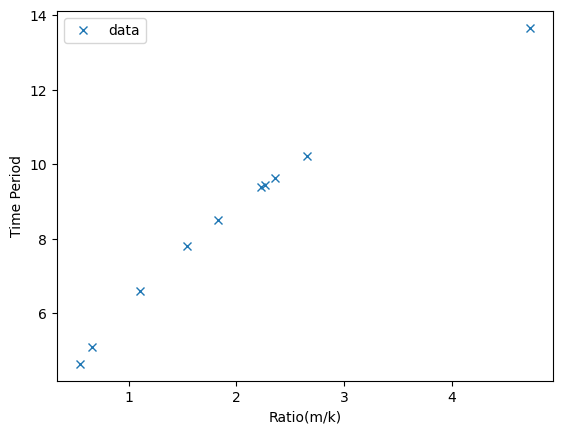

In [88]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Convert lists to numpy arrays for fitting
m_values = np.array(m_values)
k_values = np.array(k_values)
T_simulated = np.array(T_simulated)
R = np.array(m_values/k_values)

print("m_values =",m_values)
print("k_values =",k_values)
print("T_simulated=",T_simulated)
print("Ratio = ", R)

#making plot of T_stimulated vs Ratio R
plt.plot(R,T_simulated,'x',label="data")
plt.xlabel("Ratio(m/k)")
plt.ylabel("Time Period")
plt.legend()
plt.show()

Best fit to a powerlaw: y = 6.285012*x^0.499313


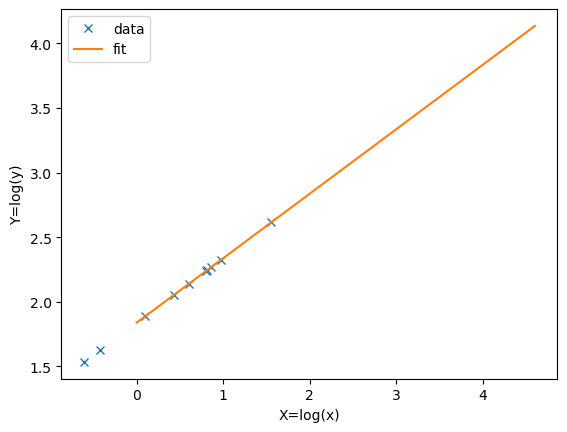

In [86]:
# Define new variables
X = np.log(R)
Y = np.log(T_simulated)

# Fit a first degree polynomial
p = np.polyfit(X, Y, 1)
a=p[0]  # Exponent of powerlaw
B=p[1]  # Logarithm of prefactor
b=np.exp(B)  # Prefactor
# Print the result

print("Best fit to a powerlaw: y = %f*x^%f" % (b,a))

# Plot the fit
Xfit = np.arange(0, np.log(100), 0.1)
Yfit = np.polyval(p, Xfit)
plt.plot(X,Y,'x',label="data")
plt.plot(Xfit, Yfit, '-', label="fit")

plt.legend()
plt.xlabel("X=log(x)")
plt.ylabel("Y=log(y)")
plt.show()

Exercise 9. Compare your results with the analytical solution. To find the
analytical simulation, first combine Eqs. (2), (4) and (7) to derive that the
position as a function of time fulfills the differential equation:
x(t) = −
m
k
d
2x(t)
dt2
(16)
Now, from your simulations, you might be able to “guess” a function x(t) and
show that it is consistent with this differential equation.
![Ex.9](e9.jpg)

Exercise 10. Use simulations to answer the following research-question:
Under which conditions does the spring-mass system you been simulating exhibit a resonance? To test this, you should add a small extra oscillating force –
we call the extra force a “pertubation” of the system:
Fe = 0.01*cos(2*pi*t/Te);
T e is the period of this extra force – it should be a new input-parameter
to your program. Think of the extra force as mimicking the effect of the wind
or pedastrians on a bridge. Modify your program so that this extra force is
included in the simulation, and save it under a new name.
The following simulations should be purely driven oscillations, thus x0 = 0
and v0 = 0, and it will be useful to make simulations where tend is eg. 50 times
the natural period for your chosen m and k. Try varying the period of the
extra force, T e – Is there a period which results in large effects even though the
pertubation is small? Try plotting the maximum value of x(t) versus T e. What


Answer: Firstly, we introduce a small oscillating external for Fe and the system was simulated using leap frog as before. First  we modified the simulation program ro include the force Fe and ran it for specific Te = 10second, and plotting mass's postion against time, it shows the system's behaviour for specific time Te. Then we ran many simulation, each time a different Te ranging from 1 to 20. and we plot the maximum displacement against Te. here, we can see the clear peak when Te is close to system's natural period about 8.89 second.  This peak indicates resonance, and system vibrates most strongly when the external force's period matches the system's natural period.

we can find system natural period as t = 2 *pie sqroot.(m/k) which is is happening?

In [91]:
def LeapFrog_extra(m, k, dt, t_end, v0, x0, Te):
    """ Run a numerical simulation of a mass and a spring using Leap-Frog.
    Parameters:
        m: mass
        k: spring constant
        dt: timestep
        t_end: total amount step
        v0: initial velocity
        x0: initial position
        Te: time period of extra force
    Returns:
        ttable: table with time
        xtable: table with position
        vtable: table with velocity
    """
    
    n_steps = int(t_end/dt)  # Number of steps
    
    ttable = np.zeros(n_steps)
    xtable = np.zeros(n_steps)
    vtable = np.zeros(n_steps)
    
    t = 0.0
    x = x0
    v = v0
    
    for i in range(n_steps):
        t = t + dt
        Fextra =  0.01*np.cos(2*np.pi*t/Te);
        a = -(k*x)/m + Fextra/m
        v = v + a*dt  # a = dv/dt
        x = x + v*dt  # v = dx/dt
        
        ttable[i] = t
        xtable[i] = x
        vtable[i] = v
    
    return ttable, xtable, vtable

In [94]:
ttable,xtable,vtable = LeapFrog_extra(m=2, k=1, dt=0.1, t_end=100, v0=0, x0=0, Te=10) 

In [12]:
##print(ttable)
##print(xtable)
##print(vtable)

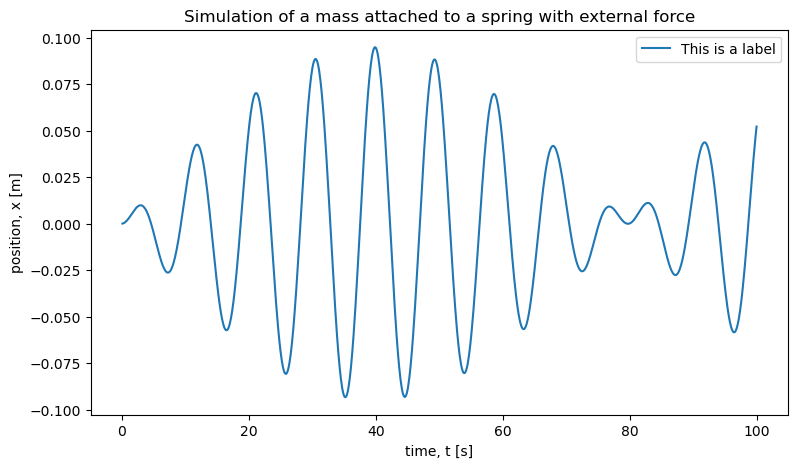

In [95]:
plt.figure(figsize=(9, 5))
plt.plot(ttable,xtable,'-', label='This is a label')
plt.title("Simulation of a mass attached to a spring with external force")
plt.xlabel("time, t [s]")
plt.ylabel("position, x [m]")
plt.legend()
plt.savefig('resonance.pdf')
plt.show()

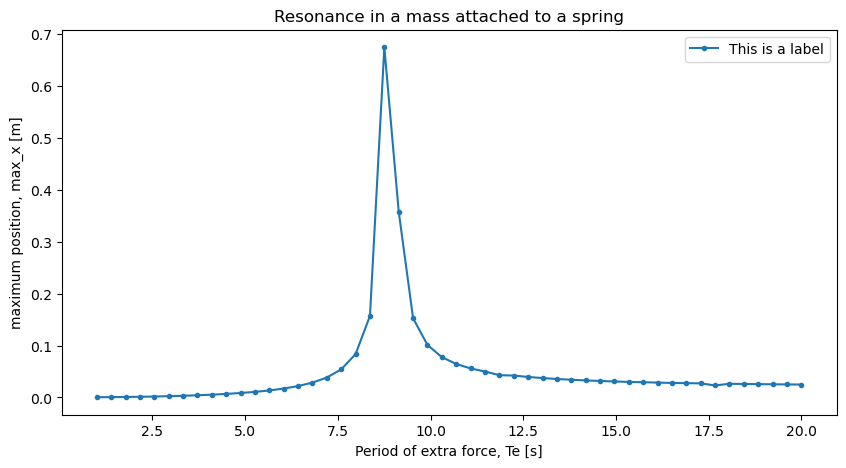

In [77]:
#If you find the resonance difficult to find, you can make a lot of simulations in one step (be carefull that it does not take to long):

Te_table = np.linspace(1, 20, 50)
max_x = np.zeros_like(Te_table)

for i, Te in enumerate(Te_table):
    ttable,xtable,vtable = LeapFrog_extra(m=2, k=1, dt=0.1, t_end=400, v0=0.0, x0=0.0, Te=Te)
    max_x[i] = np.max(xtable)

plt.figure(figsize=(10, 5))
plt.plot(Te_table, max_x, '.-', label='This is a label')
plt.title("Resonance in a mass attached to a spring")
plt.xlabel("Period of extra force, Te [s]")
plt.ylabel("maximum position, max_x [m]")
plt.legend()
plt.savefig('resonance.pdf')
plt.show()


## Experimental Part


6. Does the measured amplitude match the amplitude you have chosen on the generator? Explain how you see that.

Ans: ![Physics Experiment](Ex6.jpg)
    we have choosen the amplitude as 1.25 V and in the image we can see that from the origin, the height of peak is 1.15 V.
o the phase angle?


7. Does this match the frequency you have chosen on the generator? You need to
make a little calculation to show this.

Ans: We have chosen frequency 4KHz, which is 4000Hz and in the image we can see that Time period, i.e. the distance between two peak or two lows is around 250 microsecond, we can do this by counting the box between two highs or two lows each box is 50 microsecond . Using the formula f= 1/T, we get , 1 / 250 * 10^-6 Hz = 4000Hz = 4KHz.






13. Connect the circuit board to the oscilloscope such that the voltage over the known
resistor is measured on chanal 2 (Ch 2). Press Ch 2. Measure U2 and calculate
the current running through the known resistor.

Ans: we did as required and find that U2 peak-peak as 354mV(from the oscilloscope,). so our U2 = 354/2 = 176mV = 0.176V
 and using the given eqn we find the current as U2/10 here 10 is known resistance
     hence, the current I = 0.0176 Ampere 
 here the current is  same in both resistor as they are in series 


14 Measure U1 and use the current (I from equation 8) to find the resistance of the
unknown resistor (Ru). 

Ans: U1 peak to peak is 18.25 which mean U1 is 9.125 V which will gives us R as 9.125/0.0176 which is 518.46ohm


EX.16 Vary the frequency and measure the voltage drop, U1, and the current, I = U2/10Ω
at least 10 frequencies in the range 2 kHz to 20 kHz. Report the data in a script
as the one shown below and include it in your report

![Physics Experiment](pic.jpg)

: At resonance, Phase angle is zero as U1 and U2 align perfectly. Below resonance, phase angle is less than zero and above resonance phase angle is greater than zero.

U1 = [10.1   10.025  9.9    6.4    2.715  7.4    8.81   9.76   9.85   9.89
  9.9  ]
y = [0.0895 0.2105 0.3045 1.18   1.465  1.03   0.725  0.3365 0.2745 0.23
 0.2135]
current = [0.00895 0.02105 0.03045 0.118   0.1465  0.103   0.0725  0.03365 0.02745
 0.023   0.02135]
quantity I/U1 = [0.00088614 0.00209975 0.00307576 0.0184375  0.05395948 0.01391892
 0.00822928 0.00344775 0.0027868  0.00232558 0.00215657]


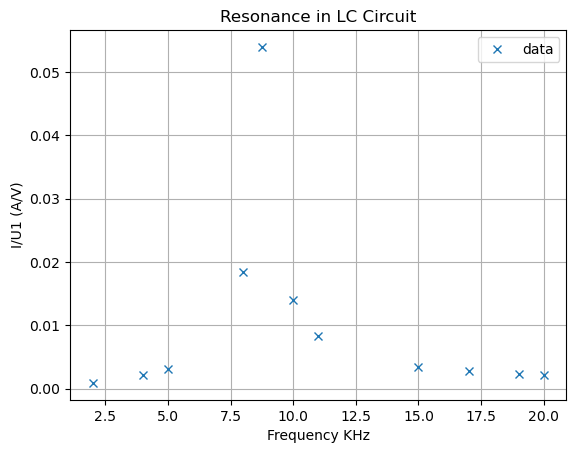

In [26]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
#red inductance

# i n p u t
f = np . array ( [2, 4, 5, 8, 8.7722, 10, 11, 15, 17, 19, 20 ] ) # f r e q u n c y , u ni t kHz
ppU1 = np . array ( [ 20.2, 20.05, 19.8, 12.8, 5.43, 14.8, 17.62, 19.52, 19.7, 19.78, 19.8] ) # peak t o peak v ol t a g e 1 , u ni t Vol t
ppU2 = np . array ( [ 0.179, 0.421, 0.609, 2.36, 2.93, 2.06, 1.45, 0.673, 0.549, 0.460, 0.427] ) # peak t o peak v ol t a g e 2 , u ni t Vol t

# c a l c u l a t e d q u a n t i t i e s
U1 = np.array(ppU1/2) # ampli tude v ol t a g e 1 , u ni t Vol t
U2 = np.array(ppU2/2) # ampli tude v ol t a g e 2 , u ni t Vol t
I = np.array(U2/10 )# ampli tude c u r r e n t , u ni t Ampere
quantity = np.array(I/U1)

print("U1 =",U1)
print("y =",U2)
print("current =",I)
print("quantity I/U1 =",quantity)

#making plot of quantity vs frequency
plt.plot(f,quantity,'x',label="data")
plt.xlabel("Frequency KHz")
plt.ylabel("I/U1 (A/V)")
plt.title("Resonance in LC Circuit")
plt.legend()
plt.grid()
plt.show()


Here, we removed the unknown register and connected capacitor and the red inductor in series forming an electrical ossillator and we vary the frequency in the range of 2KHz and 20KHz and collected data for peak to peak Voltage 1 and peak to peak Voltage 2. we calculated current I = U2/10 , here 10 ohm is the known resistor se put them into numpy arrays and and plotting the I/U1 as function of frequency.

Here, to find the resonance, from the collected data we found out the peak lies between 8KHz and 10KHz, then we narrowed the frequency range and adjust it slowly while observing the phase angle between U1 and U2 on the oscilloscope. The exact resonance frequency is where the phase angle becomes zero. For this experiment, the resonance frequency was found to be approximately 8.7722 KHz.

Calculation of Time period corresponding to resonance frequency
T = 1/f
here T is time period corresponding to resonance frequeny (f)

f = 8.7722KHz = 8.7722 * 10^3 Hz
T = 1/f = 114us 


EX. 20 The exercise is repeated with all the different inductors and it is studied how
the resonance shifts depend on the self-inductance. Report the data in a script,
remember units and think about the number of digits.

we repeat the similar process for pink  inductance and found their resonance frequency to be 12.94KHz and

U1 = [10.1   10.035  9.9    8.45   7.4    6.95   2.475  6.715  8.5    9.15
  9.305]
y = [0.087  0.1855 0.245  0.855  1.03   1.13   1.515  1.16   0.825  0.64
 0.57  ]
current = [0.0087  0.01855 0.0245  0.0855  0.103   0.113   0.1515  0.116   0.0825
 0.064   0.057  ]
quantity I/U1 = [0.00086139 0.00184853 0.00247475 0.01011834 0.01391892 0.01625899
 0.06121212 0.01727476 0.00970588 0.00699454 0.00612574]


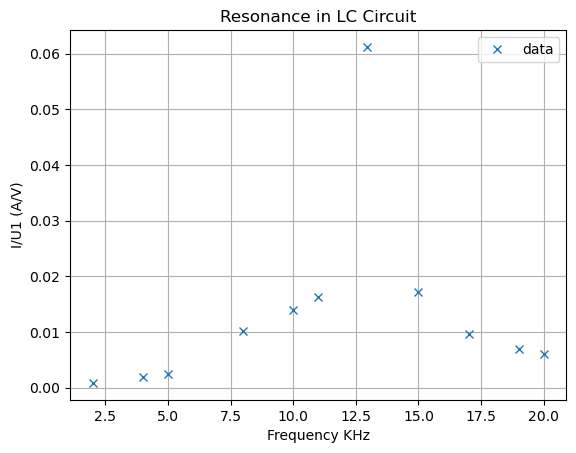

In [30]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
# for pink inductance
# i n p u t
f = np . array ( [2, 4, 5, 8, 10, 11, 12.94, 15, 17, 19, 20 ] ) # f r e q u n c y , u ni t kHz
ppU1 = np . array ( [ 20.2, 20.07, 19.8, 16.9, 14.8, 13.9, 4.95, 13.43, 17, 18.3, 18.61] ) # peak t o peak v ol t a g e 1 , u ni t Vol t
ppU2 = np . array ( [ 0.174, 0.371, 0.490, 1.71, 2.06, 2.26, 3.03, 2.32, 1.65, 1.28, 1.14] ) # peak t o peak v ol t a g e 2 , u ni t Vol t

# c a l c u l a t e d q u a n t i t i e s
U1 = np.array(ppU1/2) # ampli tude v ol t a g e 1 , u ni t Vol t
U2 = np.array(ppU2/2) # ampli tude v ol t a g e 2 , u ni t Vol t
I = np.array(U2/10 )# ampli tude c u r r e n t , u ni t Ampere
quantity = np.array(I/U1)

print("U1 =",U1)
print("y =",U2)
print("current =",I)
print("quantity I/U1 =",quantity)

#making plot of quantity vs frequency
plt.plot(f,quantity,'x',label="data")
plt.xlabel("Frequency KHz")
plt.ylabel("I/U1 (A/V)")
plt.title("Resonance in LC Circuit")
plt.legend()
plt.grid()
plt.show()


## Conclusion

The simulation of mass-spring system and the experimental analysis of the electrical circuit both demonstrate the fundamental principles of oscillaroty motion and resonance. In the simulation, we modeled a mass-spring system using the Leap-Frog numerical method, observing how the system oscillates and how its period depends on the ratio k/m. Similarly, in the experimental part we analyzed the circuit varying the frequency to identify resonance. We identified resonance as the frequency where the quantity I/U1 reached its maximum value, where the system responds most strongly to the input signal.

The simulation procides theoThe simulation provides a theoritical foundation of oscillatory motion while experiment provides practical insights, reinforcing the concept that resoance occurs when the driving frequency matches the syste,